# GraphCast: RMSE and skill-score plots

Plotting only -- reads precomputed forecast-error arrays, so no GraphCast
checkpoint or model run is needed. See `run_forecasts.ipynb` for how those arrays
were produced.

Produces four of the paper's figures:

- `rmse_and_skill_score_24h.jpeg`
- `graphcast_rmse_vs_leadtime.jpeg`
- `speedyweather_rmse_vs_leadtime.jpeg`
- `rmse_by_transform_and_season.jpeg`

They do not all draw on the same inputs. The first and last are built from
GraphCast's own error arrays and the ERA5 climatology; the middle two additionally
use the SpeedyWeather error files produced by
`../SpeedyWeather/run_tests.ipynb`. Note that the
Config cell below expects all three Zenodo record identifiers regardless, so a
straight top-to-bottom run downloads the SpeedyWeather files even if you only want
the two figures that do not use them.

## Config


In [1]:
import sys, os
sys.path.insert(0, "../common")
from zenodo_fetch import ensure_zenodo_files

DATA_DIR = "../data/GraphCast"
SPEEDYWEATHER_DATA_DIR = "../data/SpeedyWeather/paper_original"

# --- TEMPORARY: data is on Zenodo's sandbox while the paper is under review ---
# Sandbox records are periodically wiped and their DOIs (10.5072/...) are not
# real. When the record is published on the real Zenodo, delete these two lines
# and replace the record id(s) below with the real one(s).
import os
os.environ["ZENODO_BASE_URL"] = "https://sandbox.zenodo.org"
# -----------------------------------------------------------------------------

# The data comes from three separate Zenodo records, split because of the
# per-record size limit. See README.md for what is in each.
ZENODO_RECORD_GRAPHCAST_ERA5 = "586387"          # regridded ERA5 + climatology
ZENODO_RECORD_GRAPHCAST_PREDICTIONS = "588730"   # prediction .npy error arrays
ZENODO_RECORD_SPEEDYWEATHER = "586391"           # SpeedyWeather paper_original .nc files

# The figures below are written here.
os.makedirs("figures", exist_ok=True)


## Imports


In [2]:
import datetime
import numpy as np
import xarray
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature


## Load base data -- regridded ERA5 and 30-year climatology


In [3]:
ensure_zenodo_files(ZENODO_RECORD_GRAPHCAST_ERA5, {
    "regridded_era5_data_for_GraphCast.nc": "a631b97f74850cae3a2855853a548527",
}, DATA_DIR)
reduced_era5_coarsened_test = xarray.open_dataset(f"{DATA_DIR}/regridded_era5_data_for_GraphCast.nc", engine="netcdf4")


In [4]:
lat_weights = np.cos(np.radians(reduced_era5_coarsened_test.lat))
lat_weights = lat_weights.values.reshape(1, 1, -1, 1)


In [5]:
def compute_mse_latlon(error, lat_weights, chunk_size=30):
    d, t, nlat, nlon = error.shape
    lat_weights_reshaped = lat_weights.reshape(1, 1, nlat, 1)

    # 1. Pre-calculate the average weight (scalar)
    # This is effectively (Sum of Weights) / (N_lat * N_lon)
    weights_mean = lat_weights_reshaped.mean() 
    
    mse = np.zeros((d, t))
    
    for i in range(0, d, chunk_size):
        i_end = min(i + chunk_size, d)
        chunk = error[i:i_end, :,:,:]
        
        # 2. Apply weights
        weighted_sq_error = (chunk ** 2) * lat_weights_reshaped
        
        # 3. Compute mean and normalize by weight average
        # This results in: Sum(error^2 * w) / Sum(w)
        mse[i:i_end] = weighted_sq_error.mean(axis=(2, 3)) / weights_mean
        
    return mse


## Load GraphCast prediction error arrays

2m-temperature error arrays for each test case -- `revlon` (longitude
reversed), `rotlon` (longitude rotated 180 deg) and `revlat` (latitude
reversed) -- against ERA5, both the corrected and baseline variants. See
`run_forecasts.ipynb` for how these were produced.


In [6]:
# The canonical test-case names are baseline / revlon / revlat / rotlon -- used
# on Zenodo, in the paper, and by the variables below. The on-disk directories
# keep the original working spellings: not_flipped, axis_flip, equatorial_flip
# and shift_180 respectively.
#
# Six of these seven arrays share two filenames between them and are told apart
# only by their variant directory. A Zenodo record is a flat list of files with
# no directories, so each is stored there under the "<variant>__<name>" name in
# the pair below, and unpacked into the directory layout the notebooks expect.
ensure_zenodo_files(ZENODO_RECORD_GRAPHCAST_PREDICTIONS, {
    "predictions/not_flipped/error_2mT_era5.npy":
        ("baseline__error_2mT_era5.npy", "dd54decad5038f41162441ae504f98f0"),
    "predictions/axis_flip/incl_flipped_wind/error_2mT_era5_corrected.npy":
        ("revlon__error_2mT_era5_corrected.npy", "2ea53257a548d25b94cc1b1f763e150c"),
    "predictions/shift_180/minus_12h/error_2mT_era5_corrected.npy":
        ("rotlon__error_2mT_era5_corrected.npy", "1ae8fcf61517b5f7ca3ad3d9c15dd0e0"),
    "predictions/equatorial_flip/incl_flipped_wind/error_2mT_era5_corrected.npy":
        ("revlat__error_2mT_era5_corrected.npy", "fc91a2c766e8c40ebf64ccb90f9e00b5"),
    "predictions/axis_flip/incl_flipped_wind/error_2mT_era5_corrected_baseline.npy":
        ("revlon__error_2mT_era5_corrected_baseline.npy", "9ce74a4c529d59041e7eecbe3e0f21ca"),
    "predictions/shift_180/minus_12h/error_2mT_era5_corrected_baseline.npy":
        ("rotlon__error_2mT_era5_corrected_baseline.npy", "611658568a16302b403c6162b9192b8c"),
    "predictions/equatorial_flip/incl_flipped_wind/error_2mT_era5_corrected_baseline.npy":
        ("revlat__error_2mT_era5_corrected_baseline.npy", "434cc6f5c59aad4c01acb04af86b7902"),
}, DATA_DIR)


In [7]:
error_baseline = np.load(f"{DATA_DIR}/predictions/not_flipped/error_2mT_era5.npy", mmap_mode='r')


In [8]:
error_revlon = np.load(f"{DATA_DIR}/predictions/axis_flip/incl_flipped_wind/error_2mT_era5_corrected.npy", mmap_mode='r')


In [9]:
error_rotlon = np.load(f"{DATA_DIR}/predictions/shift_180/minus_12h/error_2mT_era5_corrected.npy", mmap_mode='r')


In [10]:
error_revlat = np.load(f"{DATA_DIR}/predictions/equatorial_flip/incl_flipped_wind/error_2mT_era5_corrected.npy", mmap_mode='r')


In [11]:
error_revlon_baseline = np.load(f"{DATA_DIR}/predictions/axis_flip/incl_flipped_wind/error_2mT_era5_corrected_baseline.npy", mmap_mode='r')


In [12]:
error_rotlon_baseline = np.load(f"{DATA_DIR}/predictions/shift_180/minus_12h/error_2mT_era5_corrected_baseline.npy", mmap_mode='r')


In [13]:
error_revlat_baseline = np.load(f"{DATA_DIR}/predictions/equatorial_flip/incl_flipped_wind/error_2mT_era5_corrected_baseline.npy", mmap_mode='r')


## Compute latlon-weighted MSE


In [14]:
mse_baseline_latlon =  compute_mse_latlon(error_baseline, lat_weights, 30)
mse_revlat_latlon = compute_mse_latlon(error_revlat, lat_weights, 30)
mse_rotlon_latlon = compute_mse_latlon(error_rotlon, lat_weights, 30)
mse_revlon_latlon = compute_mse_latlon(error_revlon, lat_weights, 30)


In [15]:
mse_revlat_latlon_baseline = compute_mse_latlon(error_revlat_baseline, lat_weights, 30)
mse_rotlon_latlon_baseline = compute_mse_latlon(error_rotlon_baseline, lat_weights, 30)
mse_revlon_latlon_baseline = compute_mse_latlon(error_revlon_baseline, lat_weights, 30)


## Compute t0-t4 MSE (for the skill-score figure)


In [16]:
def compute_mse_days_t0_to_t4(error, chunk_size=30): # Removed lat_weights
    d, t, nlat, nlon = error.shape
    
    # Initialize output for 4 timesteps
    total = np.zeros((4, nlat, nlon))
    count = 0
    
    for i in range(0, d, chunk_size):
        i_end = min(i + chunk_size, d)
        
        # Select first 4 timesteps
        chunk = error[i:i_end, 0:4, :, :] 

        # Square only. Do not weight.
        total += (chunk ** 2).sum(axis=0)
        
        count += chunk.shape[0]
        
    return total / count


In [17]:
mse_revlat_days_t0_t4_baseline = compute_mse_days_t0_to_t4(error_revlat_baseline, 30) #, lat_weights
mse_rotlon_days_t0_t4_baseline = compute_mse_days_t0_to_t4(error_rotlon_baseline, 30)#, lat_weights
mse_revlon_days_t0_t4_baseline = compute_mse_days_t0_to_t4(error_revlon_baseline, 30)#, lat_weights


## Climatology skill score


In [18]:
ensure_zenodo_files(ZENODO_RECORD_GRAPHCAST_ERA5, {
    "climatology/temp_climatology_timeseries_1992_to_2021.nc": "d55a5cba4d930abaa8823259682c6d47",
}, DATA_DIR)
temp_30yr_clim = xarray.open_dataset(f"{DATA_DIR}/climatology/temp_climatology_timeseries_1992_to_2021.nc")


In [19]:
all_indices = np.arange(len(temp_30yr_clim.strftime))
indices_to_drop = np.arange(59*4, 59*4 + 4) # Leap year indices
leap_mask = ~np.isin(all_indices, indices_to_drop) #in1d(all_indices, indices_to_drop)

In [20]:
temp_30yr_clim_no_leap = temp_30yr_clim.isel(strftime=leap_mask)

In [21]:
full_clim = temp_30yr_clim_no_leap['2m_temperature'].values

In [22]:
era5_2022 = reduced_era5_coarsened_test['2m_temperature'].sel(batch=0)[1:1461,:,:]


In [23]:
error_clim_era5 = full_clim - era5_2022

In [24]:
unweighted_SE_clim_era5 = (error_clim_era5  ** 2)

In [25]:
unweighted_MSE_clim_era5 = unweighted_SE_clim_era5.mean(dim='time')

In [26]:
def calculate_skill_score(mse, mse_clim):
    return 1 - (mse/ mse_clim)

In [27]:
# Used to be weighted_MSE_clim_era5.values but the weighting was actually wrong, and it's supposed to be unweighted
SS_rotlon = calculate_skill_score(mse_rotlon_days_t0_t4_baseline, unweighted_MSE_clim_era5.values) #mse_clim_days_t0_t4_baseline)
SS_revlat = calculate_skill_score(mse_revlat_days_t0_t4_baseline, unweighted_MSE_clim_era5.values) #mse_clim_days_t0_t4_baseline)
SS_revlon = calculate_skill_score(mse_revlon_days_t0_t4_baseline, unweighted_MSE_clim_era5.values) #mse_clim_days_t0_t4_baseline)

In [28]:
lons = era5_2022.lon

In [29]:
lats = era5_2022.lat

---
## Figure 1 -- Combined RMSE + Skill Score


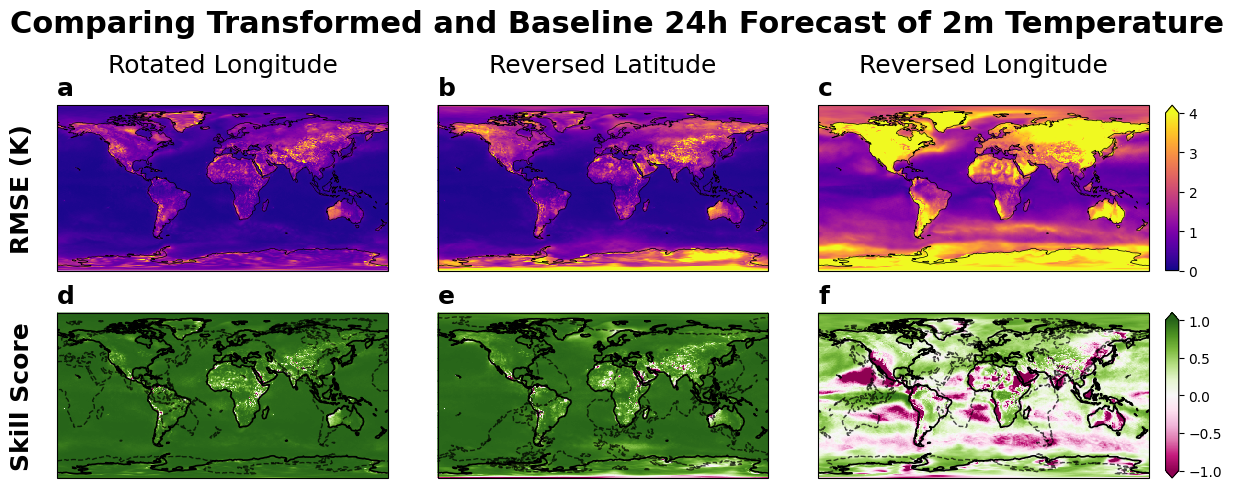

In [30]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import shapely.affinity as saffin

fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 5),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

plt.subplots_adjust(left=0.10, right=0.88, hspace=0.05, wspace=0.15, top=0.92)
row_titles = ['Rotated Longitude', 'Reversed Latitude', 'Reversed Longitude']

LABEL_Y_OFFSET = 1.03  # consistent axes-fraction offset for all letter labels

# =========================
# ---- TOP ROW: RMSE ------
# =========================
vmaxs_rmse = [4, 4, 4]
vmins_rmse = [0, 0, 0]

mappable_rmse = None

data_arrays = [
    np.sqrt(np.abs(mse_rotlon_days_t0_t4_baseline[3,:,:])),
    np.sqrt(np.abs(mse_revlat_days_t0_t4_baseline[3,:,:])),
    np.sqrt(np.abs(mse_revlon_days_t0_t4_baseline[3,:,:]))
]

top_labels = ["a", "b", "c"]

for i in range(3):
    ax = axes[0, i]
    ax.set_extent([-180, 180, -90, 90])
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    # Column title (higher up, well clear of the letter)
    ax.set_title(row_titles[i], fontsize=18, pad=24)

    # Letter label, consistent offset with bottom row
    ax.text(
        0.0, LABEL_Y_OFFSET, top_labels[i],
        transform=ax.transAxes,
        fontsize=18, fontweight="bold",
        va="bottom", ha="left"
    )

    im = ax.pcolormesh(
        lons, lats, data_arrays[i],
        transform=ccrs.PlateCarree(),
        cmap='plasma',
        vmin=min(vmins_rmse),
        vmax=max(vmaxs_rmse)
    )

    if mappable_rmse is None:
        mappable_rmse = im


# RMSE colorbar
cax1 = inset_axes(
    axes[0, -1],
    width="4%",
    height="100%",
    loc='lower left',
    bbox_to_anchor=(1.05, 0., 1, 1),
    bbox_transform=axes[0, -1].transAxes,
    borderpad=0
)

cbar1 = plt.colorbar(mappable_rmse, cax=cax1, extend='max', extendfrac=0.05)
cbar1.ax.tick_params(labelsize=10)
#cbar1.set_label("RMSE (K)", size=12)


# ===============================
# ---- BOTTOM ROW: SKILL --------
# ===============================
vmaxs_ss = [1, 1, 1]
vmins_ss = [-1, -1, -1]

mappable_ss = None

data_arrays = [SS_rotlon[3,:,:], SS_revlat[3,:,:], SS_revlon[3,:,:]]

bottom_labels = ["d", "e", "f"]

for i in range(3):
    ax = axes[1, i]
    ax.set_extent([-180, 180, -90, 90])
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=10)

    # Transformed coastlines
    if i == 0:
        ax.add_feature(
            cfeature.COASTLINE,
            linewidth=1,
            linestyle='--',
            edgecolor='black',
            alpha=0.7,
            transform=ccrs.PlateCarree(central_longitude=180)
        )

    elif i == 1:
        geoms = [saffin.scale(geom, yfact=-1, origin=(0, 0))
                 for geom in cfeature.COASTLINE.geometries()]
        ax.add_geometries(
            geoms,
            crs=ccrs.PlateCarree(),
            edgecolor='black',
            facecolor='none',
            linewidth=1,
            linestyle='--',
            alpha=0.7
        )

    elif i == 2:
        geoms = [saffin.scale(geom, xfact=-1, origin=(0, 0))
                 for geom in cfeature.COASTLINE.geometries()]
        ax.add_geometries(
            geoms,
            crs=ccrs.PlateCarree(),
            edgecolor='black',
            facecolor='none',
            linewidth=1,
            linestyle='--',
            alpha=0.7
        )

    im = ax.pcolormesh(
        lons, lats, data_arrays[i],
        transform=ccrs.PlateCarree(),
        cmap='PiYG',
        vmin=vmins_ss[i],
        vmax=vmaxs_ss[i]
    )

    if mappable_ss is None:
        mappable_ss = im

    # Letter label, same offset as top row
    ax.text(
        0.0, LABEL_Y_OFFSET, bottom_labels[i],
        transform=ax.transAxes,
        fontsize=18, fontweight="bold",
        va="bottom", ha="left"
    )

# Skill score colorbar
cax2 = inset_axes(
    axes[1, -1],
    width="4%",
    height="100%",
    loc='lower left',
    bbox_to_anchor=(1.05, 0., 1, 1),
    bbox_transform=axes[1, -1].transAxes,
    borderpad=0
)

cbar2 = plt.colorbar(mappable_ss, cax=cax2, extend='both', extendfrac=0.05)
cbar2.ax.tick_params(labelsize=10)
#cbar2.set_label("Skill Score", size=12)

# =========================
# ---- LEFT ROW LABELS ----
# =========================
fig.canvas.draw()

top_row_pos = axes[0, 0].get_position()
bottom_row_pos = axes[1, 0].get_position()

y_top_center = top_row_pos.y0 + top_row_pos.height / 2
y_bottom_center = bottom_row_pos.y0 + bottom_row_pos.height / 2

# --- RMSE ---
fig.text(
    0.075, y_top_center,
    "RMSE (K)",
    rotation=90,
    va='center',
    ha='center',
    fontsize=18,
    weight='bold'
)

# --- Skill Score title ---
fig.text(
    0.075,  y_bottom_center,
    "Skill Score",
    rotation=90,
    va='center',
    ha='center',
    fontsize=18,
    weight='bold'
)

# --- Skill Score formula (slightly shifted right and tuned vertically) ---
#fig.text(
#    0.075, y_bottom_center - 0.0,   # <-- tweak these two numbers
#    r"$1 - \frac{\mathrm{MSE}_{\mathrm{baseline, adapted}}}"
#    r"{\mathrm{MSE}_{\mathrm{ERA5\,30yr\_clim,\,ERA5\,2022}}}$",
#    rotation=90,
#    va='center',
#    ha='center',
#    fontsize=14
#)


# =========================
# ---- MAIN TITLE ---------
# =========================
plt.suptitle(
    "Comparing Transformed and Baseline 24h Forecast of 2m Temperature",
    fontsize=22,
    y=1.08,
    weight='bold'
)

plt.savefig(
    "figures/rmse_and_skill_score_24h.jpeg",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

---
## Load SpeedyWeather RMSE data

The same error files used by `../SpeedyWeather/reproduce_published_figure/`, read
from the shared data directory rather than a second copy. They are used by the two
figures below and by nothing else in this notebook.

In [31]:
ensure_zenodo_files(ZENODO_RECORD_SPEEDYWEATHER, {
    "error_reverse_lat.nc": "280fdeba650c932d33dcfd3cafff0cbb",
    "error_reverse_lon.nc": "9afb20b58b3e416650964f3c6282c0cc",
    "error_rotate_lon.nc": "7f095aaef5728b38aae40694df1ef6cd",
}, SPEEDYWEATHER_DATA_DIR)

speedy_rev_lat_error = xarray.open_dataset(f"{SPEEDYWEATHER_DATA_DIR}/error_reverse_lat.nc", decode_times=False)
speedy_rev_lon_error = xarray.open_dataset(f"{SPEEDYWEATHER_DATA_DIR}/error_reverse_lon.nc", decode_times=False)
speedy_rot_lon_error = xarray.open_dataset(f"{SPEEDYWEATHER_DATA_DIR}/error_rotate_lon.nc", decode_times=False)


In [32]:
speedy_rev_lat_rmse = np.sqrt((speedy_rev_lat_error ** 2).mean(dim="gridpoint"))
speedy_rev_lon_rmse = np.sqrt((speedy_rev_lon_error ** 2).mean(dim="gridpoint"))
speedy_rot_lon_rmse = np.sqrt((speedy_rot_lon_error ** 2).mean(dim="gridpoint"))

---
## Figure 2 -- Combined RMSE (GraphCast + SpeedyWeather)


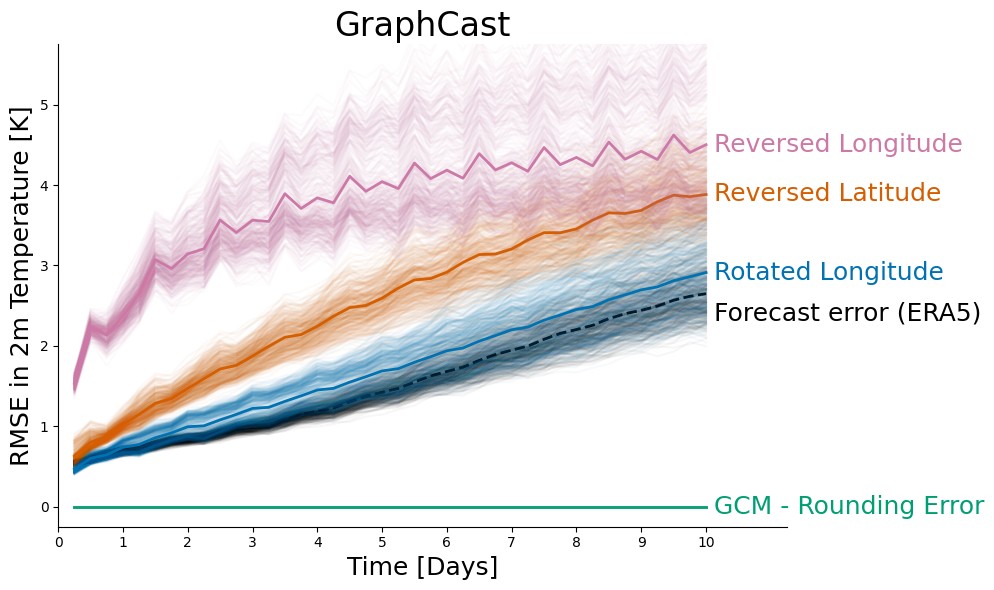

In [33]:
arrays = [
    np.sqrt(mse_baseline_latlon),
    np.sqrt(mse_rotlon_latlon_baseline),
    np.sqrt(mse_revlat_latlon_baseline),
    np.sqrt(mse_revlon_latlon_baseline)
]

more_arrays = [
    speedy_rev_lat_rmse['temperature_error'].values,
    speedy_rev_lon_rmse['temperature_error'].values,
    speedy_rot_lon_rmse['temperature_error'].values
]

colors = ['#000000', '#0072B2', '#D55E00', '#CC79A7']  # black, blue, vermillion, pink
more_colors = ['#009E73', '#009E73', '#009E73']  # teal/green
labels = ['Forecast error (ERA5)', 'Rotated Longitude', 'Reversed Latitude', 'Reversed Longitude']

#more_colors = ['orange', 'orange', 'orange']
more_labels = ['GCM - Rounding Error', '']  # Second one intentionally left blank

plt.figure(figsize=(10, 6))
x_values = np.arange(40) + 1

# Plot GCM error bands
for data, color, label in zip(more_arrays, more_colors, more_labels):
    plt.plot(x_values, data, color=color, alpha=0.8, linewidth=2)
    if label:
        plt.text(
            x_values[-1] + 0.5,
            data[-1],
            label,
            color=color,
            va='center',
            fontsize=18,
            bbox=dict(facecolor='white', edgecolor='none')
        )

for data, color, label in zip(arrays, colors, labels):
    linestyle = '--' if color == '#000000' else '-' 
    for d in range(365):
        plt.plot(x_values, data[d], color=color, alpha=0.03,)
    mean_line = data.mean(axis=0)
    plt.plot(x_values, mean_line, color=color, linewidth=2, linestyle=linestyle)

    # Adjust vertical position of black label to avoid overlap
    y_offset = -0.25 if label == 'Forecast error (ERA5)' else 0

    plt.text(
        x_values[-1] + 0.5,
        mean_line[-1] + y_offset,
        label,
        color=color,
        va='center',
        fontsize=18,
        bbox=dict(facecolor='white', edgecolor='none')
    )

# Axis formatting
plt.xticks(np.arange(0, 41, 4), np.arange(0, 11, 1))
plt.xlabel('Time [Days]', fontsize=18)
plt.ylabel('RMSE in 2m Temperature [K]', fontsize=18)
plt.title('GraphCast', fontsize=24)

# Extend x-axis range to show origin and prevent clipping of labels
plt.xlim(0, x_values[-1] + 5)
plt.ylim(-0.25, 5.75)

# Clean spine layout
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.tick_params(left=True, bottom=True, right=False, top=False)

plt.tight_layout()
plt.savefig('figures/graphcast_rmse_vs_leadtime.jpeg', dpi=600)
plt.show()

---
## Figure 3 -- SpeedyWeather RMSE only


In [34]:
more_arrays = [
    speedy_rev_lat_rmse['temperature_error'].values,
    speedy_rev_lon_rmse['temperature_error'].values,
    speedy_rot_lon_rmse['temperature_error'].values
]
x_values = np.arange(40) + 1

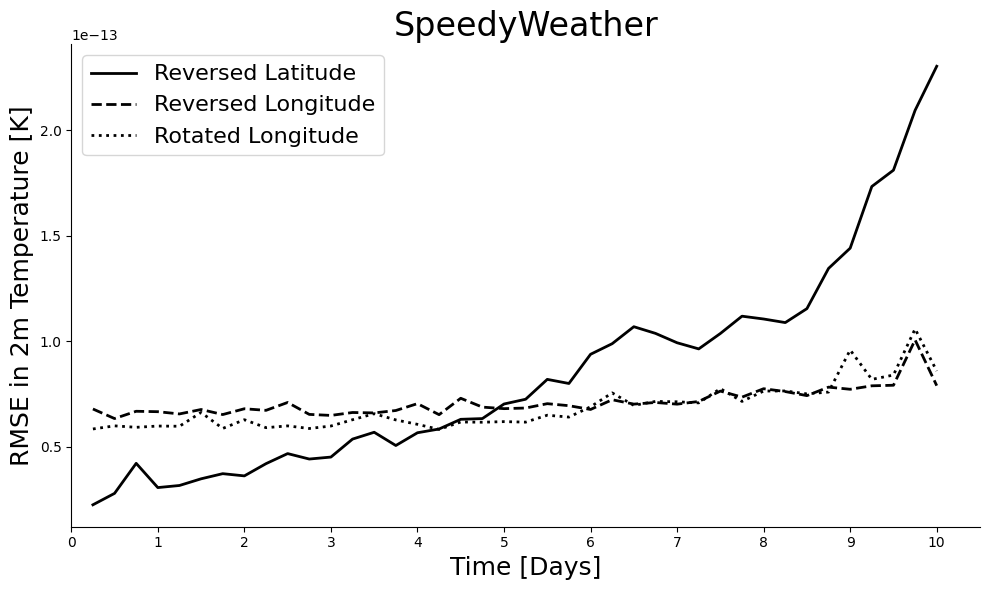

In [35]:
plt.figure(figsize=(10, 6))

labels_speedy = ['Reversed Latitude', 'Reversed Longitude', 'Rotated Longitude']
linestyles = ['-', '--', ':']

for data, label, ls in zip(more_arrays, labels_speedy, linestyles):
    plt.plot(x_values, data, color='black', linewidth=2, linestyle=ls, label=label)

plt.xlabel('Time [Days]', fontsize=18)
plt.ylabel('RMSE in 2m Temperature [K]', fontsize=18)
plt.title('SpeedyWeather', fontsize=24)
plt.xticks(np.arange(0, 41, 4), np.arange(0, 11, 1))
plt.xlim(0, x_values[-1] + 2)
plt.legend(fontsize=16)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(left=True, bottom=True, right=False, top=False)
plt.tight_layout()
plt.savefig("figures/speedyweather_rmse_vs_leadtime.jpeg", dpi=600)
plt.show()

---
## Figure 4 -- RMSE by Rotation and Season


In [36]:
def get_season_color(day_of_year):
    date = datetime.datetime(2022, 1, 1) + datetime.timedelta(days=day_of_year)
    month = date.month
    if month in [12, 1, 2]:
        return season_colors['DJF']
    elif month in [3, 4, 5]:
        return season_colors['MAM']
    elif month in [6, 7, 8]:
        return season_colors['JJA']
    else:
        return season_colors['SON']

In [37]:
arrays = [np.sqrt(mse_baseline_latlon), np.sqrt(mse_rotlon_latlon), np.sqrt(mse_revlat_latlon), np.sqrt(mse_revlon_latlon)]

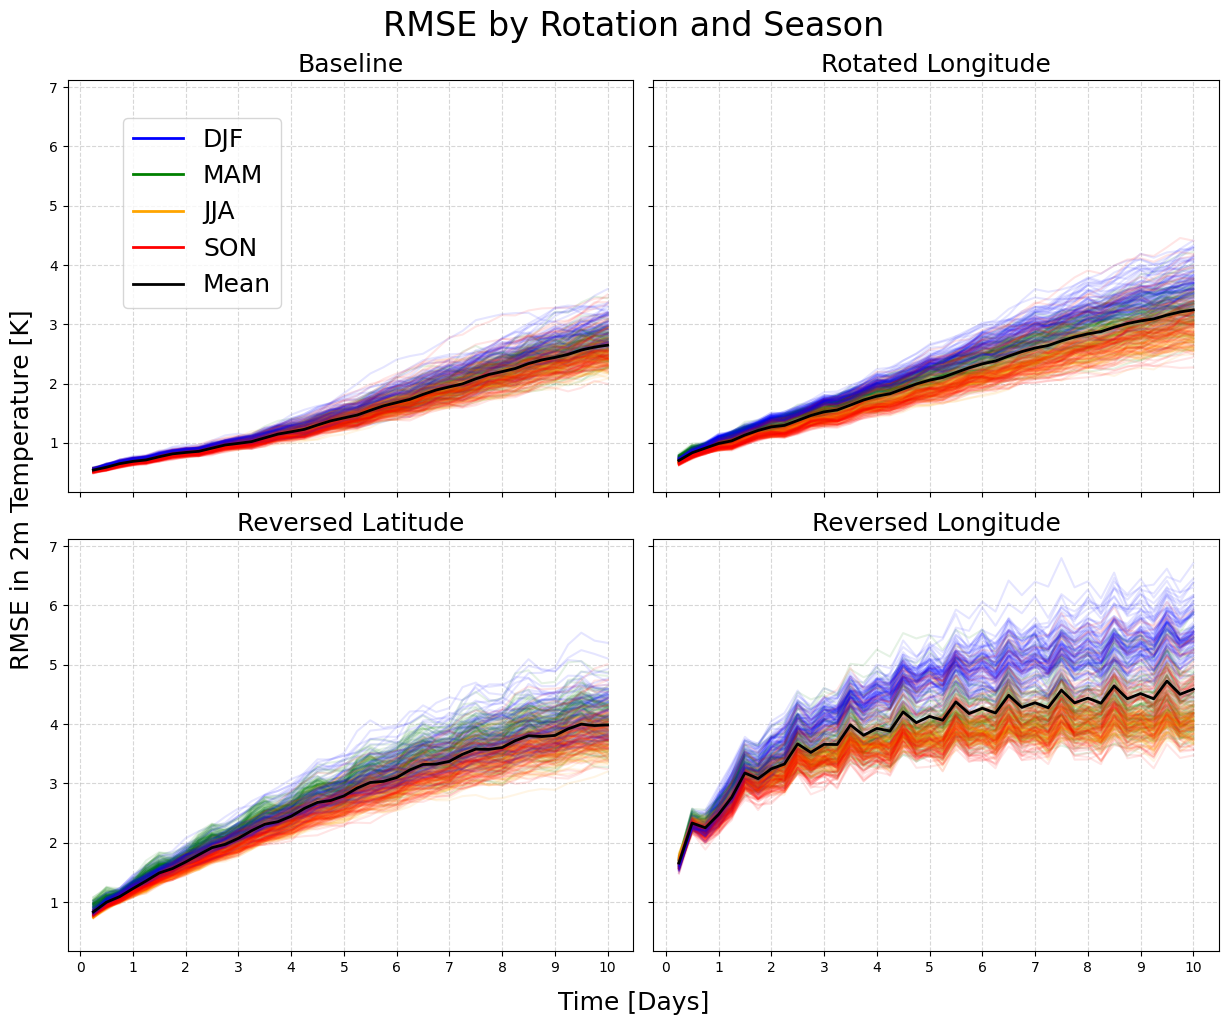

In [38]:
labels = ['Baseline', 'Rotated Longitude',  'Reversed Latitude', 'Reversed Longitude']

# Define seasonal colors
season_colors = {
    'DJF': 'blue',
    'MAM': 'green',
    'JJA': 'orange',
    'SON': 'red'
}

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
axes = axes.flatten()

x_values = np.arange(40) + 1

for i, (data, ax) in enumerate(zip(arrays, axes)):
    for d in range(365):
        season_color = get_season_color(d)
        ax.plot(x_values, data[d], color=season_color, alpha=0.1)
    
    # Plot mean line
    mean_line = data.mean(axis=0)
    ax.plot(x_values, mean_line, color='black', linewidth=2, label='Mean')
    
    ax.set_title(labels[i], fontsize=18)
    #ax.legend()
    ax.grid(True, linestyle='--', alpha=0.5)

# Set common labels
fig.text(0.5, -0.02, 'Time [Days]', ha='center', fontsize=18)
fig.text(-0.02, 0.5, 'RMSE in 2m Temperature [K]', va='center', rotation='vertical', fontsize=18)
plt.xticks(np.arange(0, 41, 4), np.arange(0, 11, 1))
plt.suptitle('RMSE by Rotation and Season', fontsize=24)
plt.tight_layout()
# Create a single legend for the entire figure
handles = [plt.Line2D([0], [0], color=color, lw=2, label=season) for season, color in season_colors.items()]
handles.append(plt.Line2D([0], [0], color='black', lw=2, label='Mean'))
fig.legend(handles=handles, loc=(0.1, 0.7), ncol=1, fontsize=18) #, frameon=False)
#plt.subplots_adjust(left=0.12, right=0.95, top=0.9, bottom=0.12)
plt.savefig('figures/rmse_by_transform_and_season.jpeg', bbox_inches='tight', dpi=800)
plt.show()